In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, root_mean_squared_error

excel = './analytical_model_results.xlsx'
ds_model_df = pd.read_excel(excel, sheet_name='DS model')

ds_model_df = ds_model_df.dropna(subset = ['N\'\'4'])
ds_model_df = ds_model_df[ds_model_df['N\'\'4']>=0]
# ds_model_df

In [5]:
bern_model_df = pd.read_excel(excel, sheet_name='Bernstein model')

bern_model_df = bern_model_df.dropna(subset = ['N\'\'4'])
bern_model_df = bern_model_df[bern_model_df['N\'\'4']>=0]
bern_model_df = bern_model_df[bern_model_df['N\'\'4']<=1]
# bern_model_df

In [6]:
r2 = r2_score(bern_model_df['N4'], bern_model_df['N\'\'4'])
bern_min = min(bern_model_df['N\'\'4'])
bern_max = max(bern_model_df['N\'\'4'])

In [7]:
from sklearn.metrics import r2_score, root_mean_squared_error
marker_set = {
    'DS Model' : '^', 
    'Bernstein Model': '8'
}

color_set = {
    'DS Model': sns.color_palette()[1],
    'Bernstein Model': sns.color_palette()[9]
}


r2_bern = r2_score(ds_model_df['N4'], ds_model_df['N\'\'4'])

ds_min = min(ds_model_df['N\'\'4'])
ds_max = max(ds_model_df['N\'\'4'])


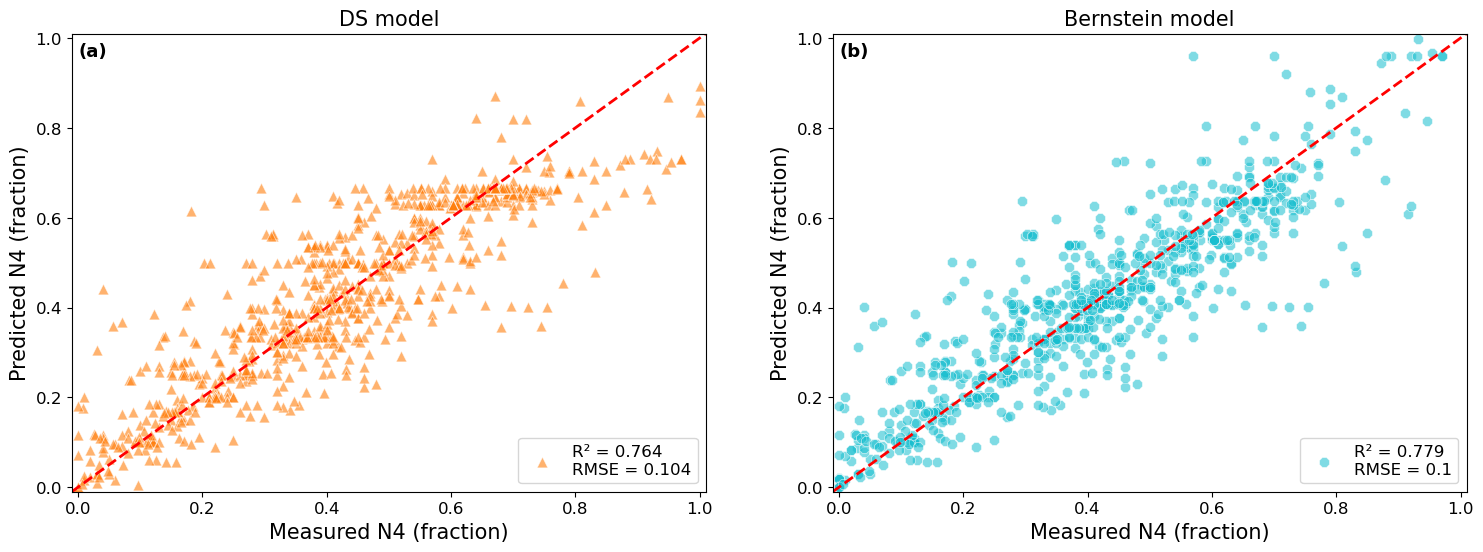

In [8]:
import matplotlib.gridspec as gridspec

titleFont = 15
labelsFont = 13
x_y_axisFont = 15
markersize = 60
linewidth = 2
labelSize = 12

plt.figure(figsize = (18,12))

gs = gridspec.GridSpec(2,2,height_ratios = [1.2,1])

plt_min=-0.01
plt_max=1.01

#plot 1: bs model
ax1 = plt.subplot(gs[0,0])
ax1.text(0.01,0.98, '(a)', transform=ax1.transAxes, fontsize=labelsFont, verticalalignment='top', fontweight = 'bold')
rmse_bs = root_mean_squared_error(ds_model_df['N4'], ds_model_df['N\'\'4'])
sns.scatterplot(x=ds_model_df['N4'], y=ds_model_df['N\'\'4'],marker=marker_set['DS Model'], color=color_set['DS Model'], alpha = 0.6, label=f'R\u00B2 = {round(r2_bern,3)} \nRMSE = {round(rmse_bs,3)}',s=60 )
ax1.plot([plt_min, plt_max], [plt_min, plt_max], 'r--', linewidth = 2)
ax1.set_xlabel('Measured N4 (fraction)', fontsize=x_y_axisFont)
ax1.set_ylabel('Predicted N4 (fraction)', fontsize= x_y_axisFont)
ax1.set_title('DS model', fontsize = titleFont)
ax1.tick_params(axis='both', labelsize=labelSize)
ax1.set_ylim(plt_min,plt_max)
ax1.set_xlim(plt_min,plt_max)
ax1.legend(fontsize= labelSize)
#plot 2
ax2=plt.subplot(gs[0,1])
ax2.text(0.01, 0.98, '(b)', transform = ax2.transAxes, fontsize=labelsFont, verticalalignment = 'top', fontweight='bold')
rmse = root_mean_squared_error(bern_model_df['N4'], bern_model_df['N\'\'4'])
sns.scatterplot(x=bern_model_df['N4'], y=bern_model_df['N\'\'4'],marker=marker_set['Bernstein Model'], color=color_set['Bernstein Model'], alpha = 0.55, label=f'R\u00B2 = {round(r2,3)} \nRMSE = {round(rmse,3)}', s=60 )
ax2.plot([plt_min, plt_max], [plt_min, plt_max], 'r--', linewidth = 2) 
ax2.set_xlabel('Measured N4 (fraction)', fontsize=x_y_axisFont)
ax2.set_ylabel('Predicted N4 (fraction)', fontsize= x_y_axisFont)
ax2.set_title('Bernstein model', fontsize = titleFont)
ax2.tick_params(axis='both', labelsize=labelSize)
ax2.set_ylim(plt_min,plt_max)
ax2.set_xlim(plt_min,plt_max)
ax2.legend(fontsize= labelSize)



In [9]:
# ds model
# N4 = Rmax = -(R''-R_D)(8+K'')/12(2+K'') R''>R_D
# Rmax cons 0.590, Rmax slope 0 0.019, Rmax = m+K''*n
# RD1 const 0.096, RD1 slope 0.502, R''D1 = o+K''*p

def ds_model(R_ds,K_ds):
    R_cons, R_slope = 0.590, 0.019
    RD1_const, RD1_slope = 0.096, 0.502

    R_max = R_cons + K_ds*R_slope
    RD1_ds = RD1_const +K_ds*RD1_slope
    if R_ds < R_max:
        n4 = R_ds
    elif R_max <= R_ds and R_ds <= RD1_ds:
        n4 = R_max
    elif R_ds > RD1_ds:
        n4 = R_max-(((R_ds-RD1_ds)*(8+K_ds))/(12*(2+K_ds))) ## R''>R_D

    # print(R_ds, R_max,n4)
    return n4

ds_df = pd.DataFrame(columns=['R"', 'K"', 'N4'])
for n in range(90): 
    for k in range (7):
        # print(float(r),float(k))
        #do n4 calculation
        r=n/10
        # print(r)
        n4_val = ds_model(float(r),float(k))
        #save into df
        ds_df.loc[len(ds_df)] = {
            'R"': float(r),
            'K"': float(k),
            'N4': n4_val
        }
ds_df['R" data'] = ds_model_df['R\'\'=([Na2O]+x[Li2O]+...)/(a[B2O3]+b[Al2O3]+...)']
ds_df['K" data'] = ds_model_df['K\'\'=([SiO2]+e[TeO2])/(a[B2O3]+b[Al2O3]+c[P2O5]+...)'] 
ds_df['N4 data'] = ds_model_df['N\'\'4']

ds_df = ds_df.dropna(subset=['N4'])


In [10]:
# bernstein equation 
# n4 = a x (b + R'') x (c - (R''/d+exK''))^5
# a = 0.147
# b = 0.37
# c = 1.42
# d cons = 4.15
# d/e slope = 1.12


def bern_model(R_bern,K_bern):
    a ,b = 0.147, 0.368
    c,d = 1.418, 4.149
    e = 1.123
    R_cons =0.43
    R_slope = 0.06
    R_max = R_cons + K_bern*R_slope
    
    if R_bern < R_max:
        n4 = R_bern
    elif R_bern >= R_max:
        n4 = a*(b+R_bern)*(c - (R_bern /(d +e*K_bern)))**5

    return n4

bern_df = pd.DataFrame(columns=['R"', 'K"', 'N4'])

for n in range(150): 
    for k in range (7):
        # print(float(r),float(k))
        #do n4 calculation
        r = n/10
        n4_val = bern_model(float(r),float(k))
        #save into df
        bern_df.loc[len(bern_df)] = {
            'R"': float(r),
            'K"': float(k),
            'N4': n4_val
        }
        
bern_df = bern_df.dropna(subset=['N4'])
bern_df['R" data'] = bern_model_df['R\'\'=([Na2O]+x[Li2O]+...)/(a[B2O3]+b[Al2O3]+...)']
bern_df['K" data'] = bern_model_df['K\'\'=([SiO2]+e[TeO2])/(a[B2O3]+b[Al2O3]+c[P2O5]+...)'] 
bern_df['N4 data'] = bern_model_df['N\'\'4']

# bern_df

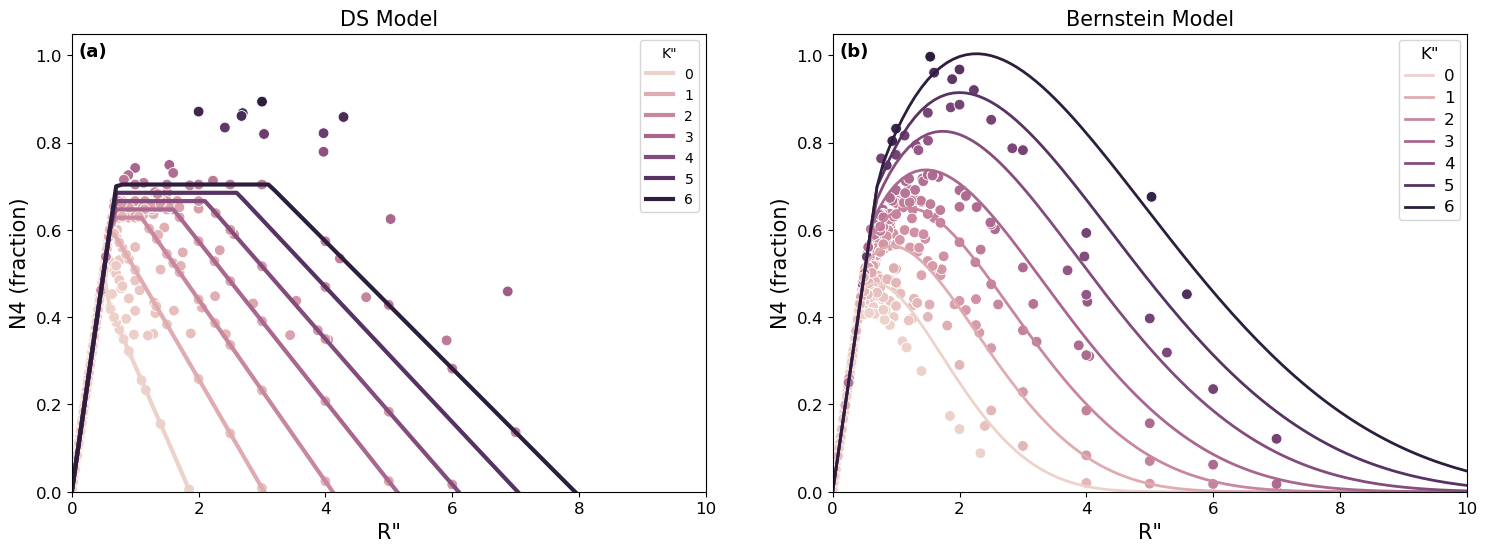

In [11]:
import matplotlib.gridspec as gridspec

palette = sns.color_palette(palette='Paired')

plt.figure(figsize = (18,12))

gs = gridspec.GridSpec(2,2,height_ratios = [1.2,1])

#plot 1: bs model
ax1 = plt.subplot(gs[0,0])
ax1.text(0.01,0.98, '(a)', transform=ax1.transAxes, fontsize=labelsFont, verticalalignment='top', fontweight = 'bold')

sns.scatterplot(data=ds_df, x = 'R" data', y = 'N4 data', hue = 'K" data', legend=False , s =markersize)
sns.lineplot(data = ds_df, x= 'R"', y="N4", hue='K"', linewidth = 3)
ax1.set_ylim(0,1.05)
ax1.set_xlim(0,10)
ax1.set_xlabel('R"', fontsize = x_y_axisFont)
ax1.set_ylabel('N4 (fraction)', fontsize = x_y_axisFont)
ax1.set_title('DS Model', fontsize =titleFont )
ax1.tick_params(axis='both', labelsize=labelSize)
plt.setp(ax2.get_legend().get_texts(), fontsize=labelSize) 
plt.setp(ax2.get_legend().get_title(), fontsize=labelSize)
#plot 2: bernstein model

ax2=plt.subplot(gs[0,1])
ax2.text(0.01, 0.98, '(b)', transform = ax2.transAxes, fontsize=labelsFont, verticalalignment = 'top', fontweight='bold')

sns.scatterplot(data=bern_df, x = 'R" data', y = 'N4 data', hue = 'K" data', legend=False, s =markersize )
sns.lineplot(data = bern_df, x= 'R"', y="N4", hue='K"',linewidth = linewidth )
ax2.set_title('Bernstein Model',fontsize = titleFont)
ax2.set_xlabel('R"', fontsize = x_y_axisFont)
ax2.set_ylabel('N4 (fraction)', fontsize = x_y_axisFont)
ax2.set_ylim(0,1.05)
ax2.set_xlim(0,10)
ax2.tick_params(axis='both', labelsize=labelSize)
plt.setp(ax2.get_legend().get_texts(), fontsize=labelSize) 
plt.setp(ax2.get_legend().get_title(), fontsize=labelSize)
plt.show()


